# X-OPT - STRUCTURAL FREQUENCY BENCHMARK

For each of the 40 OR-Library p-median instances, the workflow solves the instance using `pymedian`, retains the top-performing fraction of solutions stored in the long-term memory, builds the facility co-occurrence matrix, extracts the interpretable structures given by the maximum `k-core` and the `densest subgraph`, and compares each structure with the most frequent facilities in the analyzed memory.

The absolute frequency of a facility is the number of solutions in the analyzed memory in which that facility appears. The normalized frequency divides this count by the size of the analyzed memory, resulting in a value within the interval `[0, 1]`: `0` means that the facility never appears, while `1` means that it appears in all considered solutions.

By default, the analyzed memory corresponds to the top `10%` of the LTM sorted by cost, following the same criterion used to construct the structures in this notebook.

> Obs.: This notebook extends the structural benchmark presented in `3.0 Structural Interpretability Benchmark.ipynb`.

### SETUP

Importing libraries:

In [1]:
from __future__ import annotations

import sys
import math

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from pathlib   import Path
from time      import perf_counter


pd.set_option("display.max_columns" , None)
pd.set_option("display.max_colwidth", 140 )

plt.rcParams.update(
    {
        "figure.dpi"        : 120 ,
        "axes.grid"         : True,
        "grid.alpha"        : 0.18,
        "axes.spines.top"   : False,
        "axes.spines.right" : False,
    }
)

In [2]:
from lib.paths     import find_project_root      , \
                          instance_sort_key      , \
                          canonical_instance_name

from lib.instances import list_orlibrary_instances, \
                          read_instance_metadata  , \
                          load_best_known_costs

from lib.graph     import build_top_ltm            , \
                          build_cooccurrence_matrix, \
                          build_unweighted_graph   , \
                          total_edge_count         , \
                          total_edge_weight

from lib.explain   import densest_subgraph_greedy     , \
                          extract_highest_k_core_nodes

from lib.metrics   import compute_gap_percent

Adding the project root to the interpreter path to import `pymedian`:

In [3]:
PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


print(f"Project root is {PROJECT_ROOT}!")

Project root is /home/rei-luisinho/xopt!


In [4]:
import pymedian

### EXPERIMENT CONFIGURATION

In [5]:
INSTANCES_DIR = PROJECT_ROOT  / "instances"
PMEDOPT_PATH  = INSTANCES_DIR / "pmedopt.txt"

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "experiments_sbpo" / "artifacts"

INTERSECTIONS_CSV = OUTPUT_DIR / "structural_frequency_intersections.csv"
GROUPED_BY_N_CSV  = OUTPUT_DIR / "structural_frequency_grouped_by_n.csv"
FAILURES_CSV      = OUTPUT_DIR / "structural_frequency_failures.csv"

DEFAULT_INSTANCE_NAMES = list_orlibrary_instances(INSTANCES_DIR)
INSTANCE_NAMES         = DEFAULT_INSTANCE_NAMES


RESTARTS       = 8
MAX_ITER       = 25
FACTOR         = 0.25
DETAILS_FORMAT = "binary"

TOP_FRACTION      = 0.1
DENSEST_MIN_SIZE  = 3

SAVE_RESULTS_CSV  = True
SAVE_FAILURES_CSV = True

BEST_KNOWN_COSTS_DF = load_best_known_costs(PMEDOPT_PATH)
BEST_KNOWN_COSTS    = BEST_KNOWN_COSTS_DF.set_index("instance_id")["best_known_cost"].to_dict()

Checking parameters and instances:

In [6]:
print(f"Project root             : {       PROJECT_ROOT}")
print(f"Instances folder         : {      INSTANCES_DIR}")
print(f"Number of OR-Library runs: {len(INSTANCE_NAMES)}")

if len(INSTANCE_NAMES) != 40:
    raise ValueError(
        f"Expected 40 OR-Library p-median instances, found {len(INSTANCE_NAMES)}."
    )

Project root             : /home/rei-luisinho/xopt
Instances folder         : /home/rei-luisinho/xopt/instances
Number of OR-Library runs: 40


In [7]:
print(f"Top fraction             : {TOP_FRACTION:.0%}")
print(f"Metaheuristic parameters : restarts={RESTARTS}, max_iter={MAX_ITER}, factor={FACTOR}")

Top fraction             : 10%
Metaheuristic parameters : restarts=8, max_iter=25, factor=0.25


In [8]:
selected_instances_df = pd.DataFrame(
    [
        {
            "instance"        :      canonical_instance_name(instance_name)      ,
            "instance_id"     : Path(canonical_instance_name(instance_name)).stem,

            "best_known_cost" : BEST_KNOWN_COSTS.get(
                Path(canonical_instance_name(instance_name)).stem, np.nan,
            ),

            **read_instance_metadata(
                INSTANCES_DIR / canonical_instance_name(instance_name)
            ),
        }
        for instance_name in INSTANCE_NAMES
    ]
)

selected_instances_df["instance_order"] = selected_instances_df["instance"].map(
    lambda value: instance_sort_key(value)[0]
)


selected_instances_df = (
    selected_instances_df.sort_values(["instance_order", "instance"])
                         .drop       (columns="instance_order")
                         .reset_index(drop   =True            )
)

display(selected_instances_df)

,instance,instance_id,best_known_cost,n,p
0,pmed1.txt,pmed1,5819.0,100,5
1,pmed2.txt,pmed2,4093.0,100,10
2,pmed3.txt,pmed3,4250.0,100,10
3,pmed4.txt,pmed4,3034.0,100,20
4,pmed5.txt,pmed5,1355.0,100,33
5,pmed6.txt,pmed6,7824.0,200,5
6,pmed7.txt,pmed7,5631.0,200,10
7,pmed8.txt,pmed8,4445.0,200,20
8,pmed9.txt,pmed9,2734.0,200,40
9,pmed10.txt,pmed10,1255.0,200,67


### HELPER FUNCTIONS

In [9]:
def top_q_facilities_by_frequency(
    absolute_frequency: np.ndarray,
    q                 : int       ,
) -> set[int]:
    q = max(0, min(int(q), int(absolute_frequency.size)))

    if q == 0:
        return set()

    order = np.lexsort(
        (
             np.arange (absolute_frequency.size      ),
            -np.asarray(absolute_frequency, dtype=int),
        )
    )

    return set(
        int(facility) for facility in order[:q].tolist()
    )


def format_facilities_1_based(
    facilities: set[int] | list[int] | tuple[int, ...],
    *,
    max_items : int = 10,
) -> str:
    values = [
        int(facility) + 1
        for facility in sorted(facilities)
    ]

    if len(values) <= max_items:
        return " ".join(map(str, values))

    visible = " ".join(map(str, values[:max_items]))

    return f"{visible} ... (+{len(values) - max_items})"


def structure_overlap_stats(
    structure_nodes   : set[int]  ,
    absolute_frequency: np.ndarray,
) -> dict[str, object]:
    q = len(structure_nodes)

    top_frequency = top_q_facilities_by_frequency(absolute_frequency, q)
    intersection  = structure_nodes.intersection (top_frequency)
    union         = structure_nodes.union        (top_frequency)

    return {
        "q" : q,

        "top_frequency_nodes"     : top_frequency,
        "intersection_nodes"      : intersection ,
        "intersection_count"      : len(intersection),
        "intersection_fraction"   : len(intersection) / max(1, q         ),
        "intersection_over_union" : len(intersection) / max(1, len(union)),

        "top_frequency_nodes_1based" : format_facilities_1_based(top_frequency),
        "intersection_nodes_1based"  : format_facilities_1_based(intersection ),
    }


def build_facility_frequency_rows(
    *,
    instance_name         : str,
    instance_id           : str,
    n                     : int,
    p                     : int,
    memory_size           : int,
    frequency_memory_size : int,
    absolute_frequency    : np.ndarray,
    k_core_nodes          : set[int]  ,
    densest_nodes         : set[int]  ,
) -> list[dict[str, object]]:
    normalized_frequency = (
        np.asarray(absolute_frequency, dtype=float) / max(1, frequency_memory_size)
    )

    return [
        {
            "instance"              : instance_name        ,
            "instance_id"           : instance_id          ,
            "n"                     : n                    ,
            "p"                     : p                    ,
            "memory_size"           : memory_size          ,
            "frequency_memory_size" : frequency_memory_size,

            "facility"              : facility + 1,
            "absolute_frequency"    : int  (absolute_frequency  [facility]),
            "normalized_frequency"  : float(normalized_frequency[facility]),
            "in_k_core_max"         : facility in k_core_nodes ,
            "in_densest_subgraph"   : facility in densest_nodes,
        }
        for facility in range(n)
    ]

### BENCHMARK

In [10]:
def run_single_instance_frequency_analysis(
    instance_name: str,
    *,
    restarts        : int  ,
    max_iter        : int  ,
    factor          : int  ,
    top_fraction    : float,
    densest_min_size: int  ,
    details_format  : str = "binary",
) -> tuple[dict[str, object], list[dict[str, object]]]:
    instance_name = canonical_instance_name(instance_name)
    instance_path = INSTANCES_DIR / instance_name
    instance_id   = Path(instance_name).stem

    row: dict[str, object] = {
        "instance"        : instance_name,
        "instance_id"     : instance_id  ,
        "n"               : np.nan       ,
        "p"               : np.nan       ,
        "best_known_cost" : BEST_KNOWN_COSTS.get(instance_id, np.nan),

        "best_cost"                 : np.nan,
        "gap_percent"               : np.nan,
        "memory_size"               : np.nan,
        "frequency_memory_size"     : np.nan,
        "top_cost_cutoff"           : np.nan,
        "cooccurrence_edges"        : np.nan,
        "cooccurrence_total_weight" : np.nan,

        "k_core_max_level"                  : np.nan,
        "k_core_size"                       : np.nan,
        "k_core_top_frequency_intersection" : np.nan,
        "k_core_top_frequency_fraction"     : np.nan,
        "k_core_top_frequency_iou"          : np.nan,
        "k_core_nodes_1based"               : "",
        "k_core_top_frequency_nodes_1based" : "",
        "k_core_intersection_nodes_1based"  : "",

        "densest_subgraph_size"              : np.nan,
        "densest_subgraph_density"           : np.nan,
        "densest_top_frequency_intersection" : np.nan,
        "densest_top_frequency_fraction"     : np.nan,
        "densest_top_frequency_iou"          : np.nan,
        "densest_subgraph_nodes_1based"      : "",
        "densest_top_frequency_nodes_1based" : "",
        "densest_intersection_nodes_1based"  : "",

        "k_core_densest_subgraph_iou" : np.nan ,
        "runtime_seconds"             : np.nan ,
        "status"                      : "error",
        "error_message"               : None   ,
    }

    frequency_rows: list[dict[str, object]] = []

    if not instance_path.exists():
        row["error_message"] = f"Instance not found: {instance_path}"

        return row, frequency_rows

    metadata = read_instance_metadata(instance_path)
    row["n"] = metadata["n"]
    row["p"] = metadata["p"]

    started_at = perf_counter()

    try:
        summary, details = pymedian.solve_pmedian(
            instance_path,
            restarts      =restarts      ,
            max_iter      =max_iter      ,
            factor        =factor        ,
            details_format=details_format,
        )

        long_term_memory = details["long_term_memory"]
        if not long_term_memory:
            raise ValueError("Long term memory is empty.")

        _, matrix, costs = build_top_ltm(long_term_memory, top_fraction)
        adjacency        = build_cooccurrence_matrix(matrix   )
        unweighted_graph = build_unweighted_graph   (adjacency)

        absolute_frequency = np.asarray(matrix, dtype=int).sum(axis=0)
        frequency_size     = int(matrix.shape[0])

        _, k_core_max_level, k_core_nodes    = extract_highest_k_core_nodes(unweighted_graph)
        densest_nodes      , densest_density = densest_subgraph_greedy     (adjacency, min_size=densest_min_size)

        k_core_overlap  = structure_overlap_stats(k_core_nodes , absolute_frequency)
        densest_overlap = structure_overlap_stats(densest_nodes, absolute_frequency)

        structure_union = k_core_nodes.union       (densest_nodes)
        structure_inter = k_core_nodes.intersection(densest_nodes)
        structure_iou   = len(structure_inter) / max(1, len(structure_union))

        n = int(summary["n"])
        p = int(summary["p"])

        row.update(
            {
                "n"           : n,
                "p"           : p,
                "best_cost"   : float(summary["tspmed_cost"]),
                "gap_percent" : compute_gap_percent(
                    summary["tspmed_cost"], row["best_known_cost"],
                ),

                "memory_size"               : len(long_term_memory),
                "frequency_memory_size"     : frequency_size       ,
                "top_cost_cutoff"           : float(costs.max()   ),
                "cooccurrence_edges"        : total_edge_count (adjacency),
                "cooccurrence_total_weight" : total_edge_weight(adjacency),

                "k_core_max_level"                  : int  (k_core_max_level                         ),
                "k_core_size"                       : int  (k_core_overlap["q"                      ]),
                "k_core_top_frequency_intersection" : int  (k_core_overlap["intersection_count"     ]),
                "k_core_top_frequency_fraction"     : float(k_core_overlap["intersection_fraction"  ]),
                "k_core_top_frequency_iou"          : float(k_core_overlap["intersection_over_union"]),
                "k_core_nodes_1based"               : format_facilities_1_based(k_core_nodes         ),
                "k_core_top_frequency_nodes_1based" : k_core_overlap["top_frequency_nodes_1based"    ],
                "k_core_intersection_nodes_1based"  : k_core_overlap["intersection_nodes_1based"     ],

                "densest_subgraph_size"              : int  (densest_overlap["q"                      ]),
                "densest_subgraph_density"           : float(densest_density                           ),
                "densest_top_frequency_intersection" : int  (densest_overlap["intersection_count"     ]),
                "densest_top_frequency_fraction"     : float(densest_overlap["intersection_fraction"  ]),
                "densest_top_frequency_iou"          : float(densest_overlap["intersection_over_union"]),
                "densest_subgraph_nodes_1based"      : format_facilities_1_based(densest_nodes         ),
                "densest_top_frequency_nodes_1based" : densest_overlap["top_frequency_nodes_1based"    ],
                "densest_intersection_nodes_1based"  : densest_overlap["intersection_nodes_1based"     ],

                "k_core_densest_subgraph_iou" : structure_iou              ,
                "runtime_seconds"             : perf_counter() - started_at,
                "status"                      : "ok",
                "error_message"               : None,
            }
        )

        frequency_rows = build_facility_frequency_rows(
            instance_name = instance_name,
            instance_id   = instance_id  ,
            n             = n,
            p             = p,
            memory_size   = len(long_term_memory),

            frequency_memory_size = frequency_size    ,
            absolute_frequency    = absolute_frequency,
            k_core_nodes          = k_core_nodes      ,
            densest_nodes         = densest_nodes     ,
        )

    except Exception as exc:
        row["runtime_seconds"] = perf_counter() - started_at
        row["error_message"  ] = f"{type(exc).__name__}: {exc}"

    return row, frequency_rows

In [11]:
def run_frequency_benchmark(
    instance_names : list[str],
    *,
    restarts        : int  ,
    max_iter        : int  ,
    factor          : int  ,
    top_fraction    : float,
    densest_min_size: int  ,
    details_format  : str = "binary",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not instance_names:
        raise ValueError("The benchmark requires at least one instance.")

    rows               = []
    facility_freq_rows = []

    for instance_name in tqdm(
        instance_names,
        total        =len(instance_names             ),
        desc         ="Structural frequency benchmark",
        dynamic_ncols=True,
    ):
        row, frequency_rows = run_single_instance_frequency_analysis(
            instance_name,
            restarts        = restarts        ,
            max_iter        = max_iter        ,
            factor          = factor          ,
            top_fraction    = top_fraction    ,
            densest_min_size= densest_min_size,
            details_format  = details_format  ,
        )

        rows              .append(row)
        facility_freq_rows.extend(frequency_rows)

    intersections_df = pd.DataFrame(rows)
    frequencies_df   = pd.DataFrame(facility_freq_rows)

    intersections_df["instance_order"] = intersections_df["instance"].map(
        lambda value: instance_sort_key(value)[0]
    )

    intersections_df = (
        intersections_df.sort_values(["instance_order", "instance"])
                        .drop       (columns="instance_order")
                        .reset_index(drop   =True            )
    )

    if not frequencies_df.empty:
        frequencies_df["instance_order"] = frequencies_df["instance"].map(
            lambda value: instance_sort_key(value)[0]
        )

        frequencies_df = (
            frequencies_df.sort_values(["instance_order", "facility"])
                          .drop       (columns="instance_order")
                          .reset_index(drop   =True            )
        )

    return intersections_df, frequencies_df

### APPLY TO THE 40 INSTANCES

In [12]:
intersections_df, facility_frequency_df = run_frequency_benchmark(
    INSTANCE_NAMES,
    restarts        = RESTARTS        ,
    max_iter        = MAX_ITER        ,
    factor          = FACTOR          ,
    top_fraction    = TOP_FRACTION    ,
    densest_min_size= DENSEST_MIN_SIZE,
    details_format  = DETAILS_FORMAT  ,
)

Structural frequency benchmark:   0%|          | 0/40 [00:00<?, ?it/s]

In [13]:
success_df = intersections_df.loc[intersections_df["status"] == "ok"].copy()
failure_df = intersections_df.loc[intersections_df["status"] != "ok",
    [
        "instance"     ,
        "instance_id"  ,
        "status"       ,
        "error_message",
    ],
].reset_index(drop=True)


print(f"Successful instances   : {len(success_df           )}")
print(f"Failed instances       : {len(failure_df           )}")
print(f"Facility frequency rows: {len(facility_frequency_df)}")

if not failure_df.empty:
    display(failure_df)

Successful instances   : 40
Failed instances       : 0
Facility frequency rows: 18400


In [14]:
instance_table_columns = [
    "instance"             ,
    "n"                    ,
    "p"                    ,
    "gap_percent"          ,
    "memory_size"          ,
    "frequency_memory_size",

    "facilities_nonzero_frequency",
    "k_core_size"                 ,
    "densest_subgraph_size"       ,

    "k_core_top_frequency_intersection" ,
    "k_core_top_frequency_fraction"     ,
    "densest_top_frequency_intersection",
    "densest_top_frequency_fraction"    ,
    "k_core_densest_subgraph_iou"       ,

    "status",
]


facilities_nonzero_frequency = (
    facility_frequency_df
    .assign(
        nonzero_frequency=lambda df: df["absolute_frequency"] > 0
    )
    .groupby("instance", as_index=False)["nonzero_frequency"]
    .sum    ()
    .rename (
        columns={
            "nonzero_frequency": "facilities_nonzero_frequency"
        }
    )
)

intersections_df = intersections_df.merge(
    facilities_nonzero_frequency,
    on ="instance",
    how="left"    ,
)


instance_intersection_table = intersections_df[instance_table_columns].copy()

display(
    instance_intersection_table.style.format(
        {
            "gap_percent"                    : "{:.2f}",
            "k_core_top_frequency_fraction"  : "{:.3f}",
            "densest_top_frequency_fraction" : "{:.3f}",
            "k_core_densest_subgraph_iou"    : "{:.3f}",
        },
        na_rep="-",
    )
)

,instance,n,p,gap_percent,memory_size,frequency_memory_size,facilities_nonzero_frequency,k_core_size,densest_subgraph_size,k_core_top_frequency_intersection,k_core_top_frequency_fraction,densest_top_frequency_intersection,densest_top_frequency_fraction,k_core_densest_subgraph_iou,status
0,pmed1.txt,100,5,0.00,27,3,7,7,5,7,1.000,5,1.000,0.714,ok
1,pmed2.txt,100,10,0.00,32,4,12,12,12,12,1.000,12,1.000,1.000,ok
2,pmed3.txt,100,10,0.00,38,4,13,13,10,13,1.000,10,1.000,0.769,ok
3,pmed4.txt,100,20,0.00,62,7,23,23,20,23,1.000,20,1.000,0.870,ok
4,pmed5.txt,100,33,0.00,57,6,37,36,35,36,1.000,35,1.000,0.972,ok
5,pmed6.txt,200,5,0.00,63,7,9,8,6,8,1.000,6,1.000,0.750,ok
6,pmed7.txt,200,10,0.00,32,4,12,12,12,12,1.000,12,1.000,1.000,ok
7,pmed8.txt,200,20,0.00,34,4,22,22,22,22,1.000,22,1.000,1.000,ok
8,pmed9.txt,200,40,0.00,125,13,53,49,40,47,0.959,40,1.000,0.816,ok
9,pmed10.txt,200,67,0.00,146,15,78,77,66,77,1.000,66,1.000,0.857,ok


### TABLE GROUPED BY `n`

In [15]:
grouped_by_n_df = (
    success_df
    .merge  (
        facilities_nonzero_frequency,
        on ="instance",
        how="left"    ,
    )
    .groupby("n", as_index=False)
    .agg    (
        instances       =("instance"   , "count"),
        mean_gap_percent=("gap_percent", "mean" ),

        mean_memory_size          =("memory_size"          , "mean"),
        mean_frequency_memory_size=("frequency_memory_size", "mean"),

        mean_facilities_nonzero_frequency=("facilities_nonzero_frequency", "mean"),
        mean_k_core_size                 =("k_core_size"                 , "mean"),
        mean_densest_subgraph_size       =("densest_subgraph_size"       , "mean"),

        mean_k_core_intersection          =("k_core_top_frequency_intersection" , "mean"),
        mean_densest_intersection         =("densest_top_frequency_intersection", "mean"),
        mean_k_core_intersection_fraction =("k_core_top_frequency_fraction"     , "mean"),
        mean_densest_intersection_fraction=("densest_top_frequency_fraction"    , "mean"),
        mean_k_core_densest_iou           =("k_core_densest_subgraph_iou"       , "mean"),
    )
    .sort_values("n"      )
    .reset_index(drop=True)
)


display(
    grouped_by_n_df.style.format(
        {
            "mean_gap_percent"                  : "{:.3f}",
            "mean_memory_size"                  : "{:.2f}",
            "mean_frequency_memory_size"        : "{:.2f}",
            "mean_facilities_nonzero_frequency" : "{:.2f}",
            "mean_k_core_size"                  : "{:.2f}",
            "mean_densest_subgraph_size"        : "{:.2f}",

            "mean_k_core_intersection"           : "{:.2f}",
            "mean_densest_intersection"          : "{:.2f}",
            "mean_k_core_intersection_fraction"  : "{:.3f}",
            "mean_densest_intersection_fraction" : "{:.3f}",
            "mean_k_core_densest_iou"            : "{:.3f}",
        }
    )
)

,n,instances,mean_gap_percent,mean_memory_size,mean_frequency_memory_size,mean_facilities_nonzero_frequency,mean_k_core_size,mean_densest_subgraph_size,mean_k_core_intersection,mean_densest_intersection,mean_k_core_intersection_fraction,mean_densest_intersection_fraction,mean_k_core_densest_iou
0,100,5,0.000,43.20,4.80,18.40,18.20,16.40,18.20,16.40,1.000,1.000,0.865
1,200,5,0.000,80.00,8.60,34.80,33.60,29.20,33.20,29.20,0.992,1.000,0.885
2,300,5,0.012,104.00,10.80,53.20,47.80,42.00,47.60,42.00,0.998,1.000,0.886
3,400,5,0.015,161.40,16.60,68.40,62.80,56.40,60.60,56.40,0.982,1.000,0.912
4,500,5,0.000,190.20,19.20,89.60,75.00,67.40,72.80,67.40,0.987,1.000,0.829
5,600,5,0.064,244.20,24.80,109.80,96.40,84.00,93.80,83.80,0.985,0.999,0.841
6,700,4,0.017,187.75,19.25,76.25,65.00,59.00,62.25,59.00,0.978,1.000,0.835
7,800,3,0.000,171.67,17.67,42.00,37.67,32.67,37.67,32.67,1.000,1.000,0.784
8,900,3,0.013,180.33,18.67,49.67,40.00,37.00,39.33,37.00,0.993,1.000,0.903


### HISTOGRAMS ANALYSIS

Absolute frequency histograms per instance:

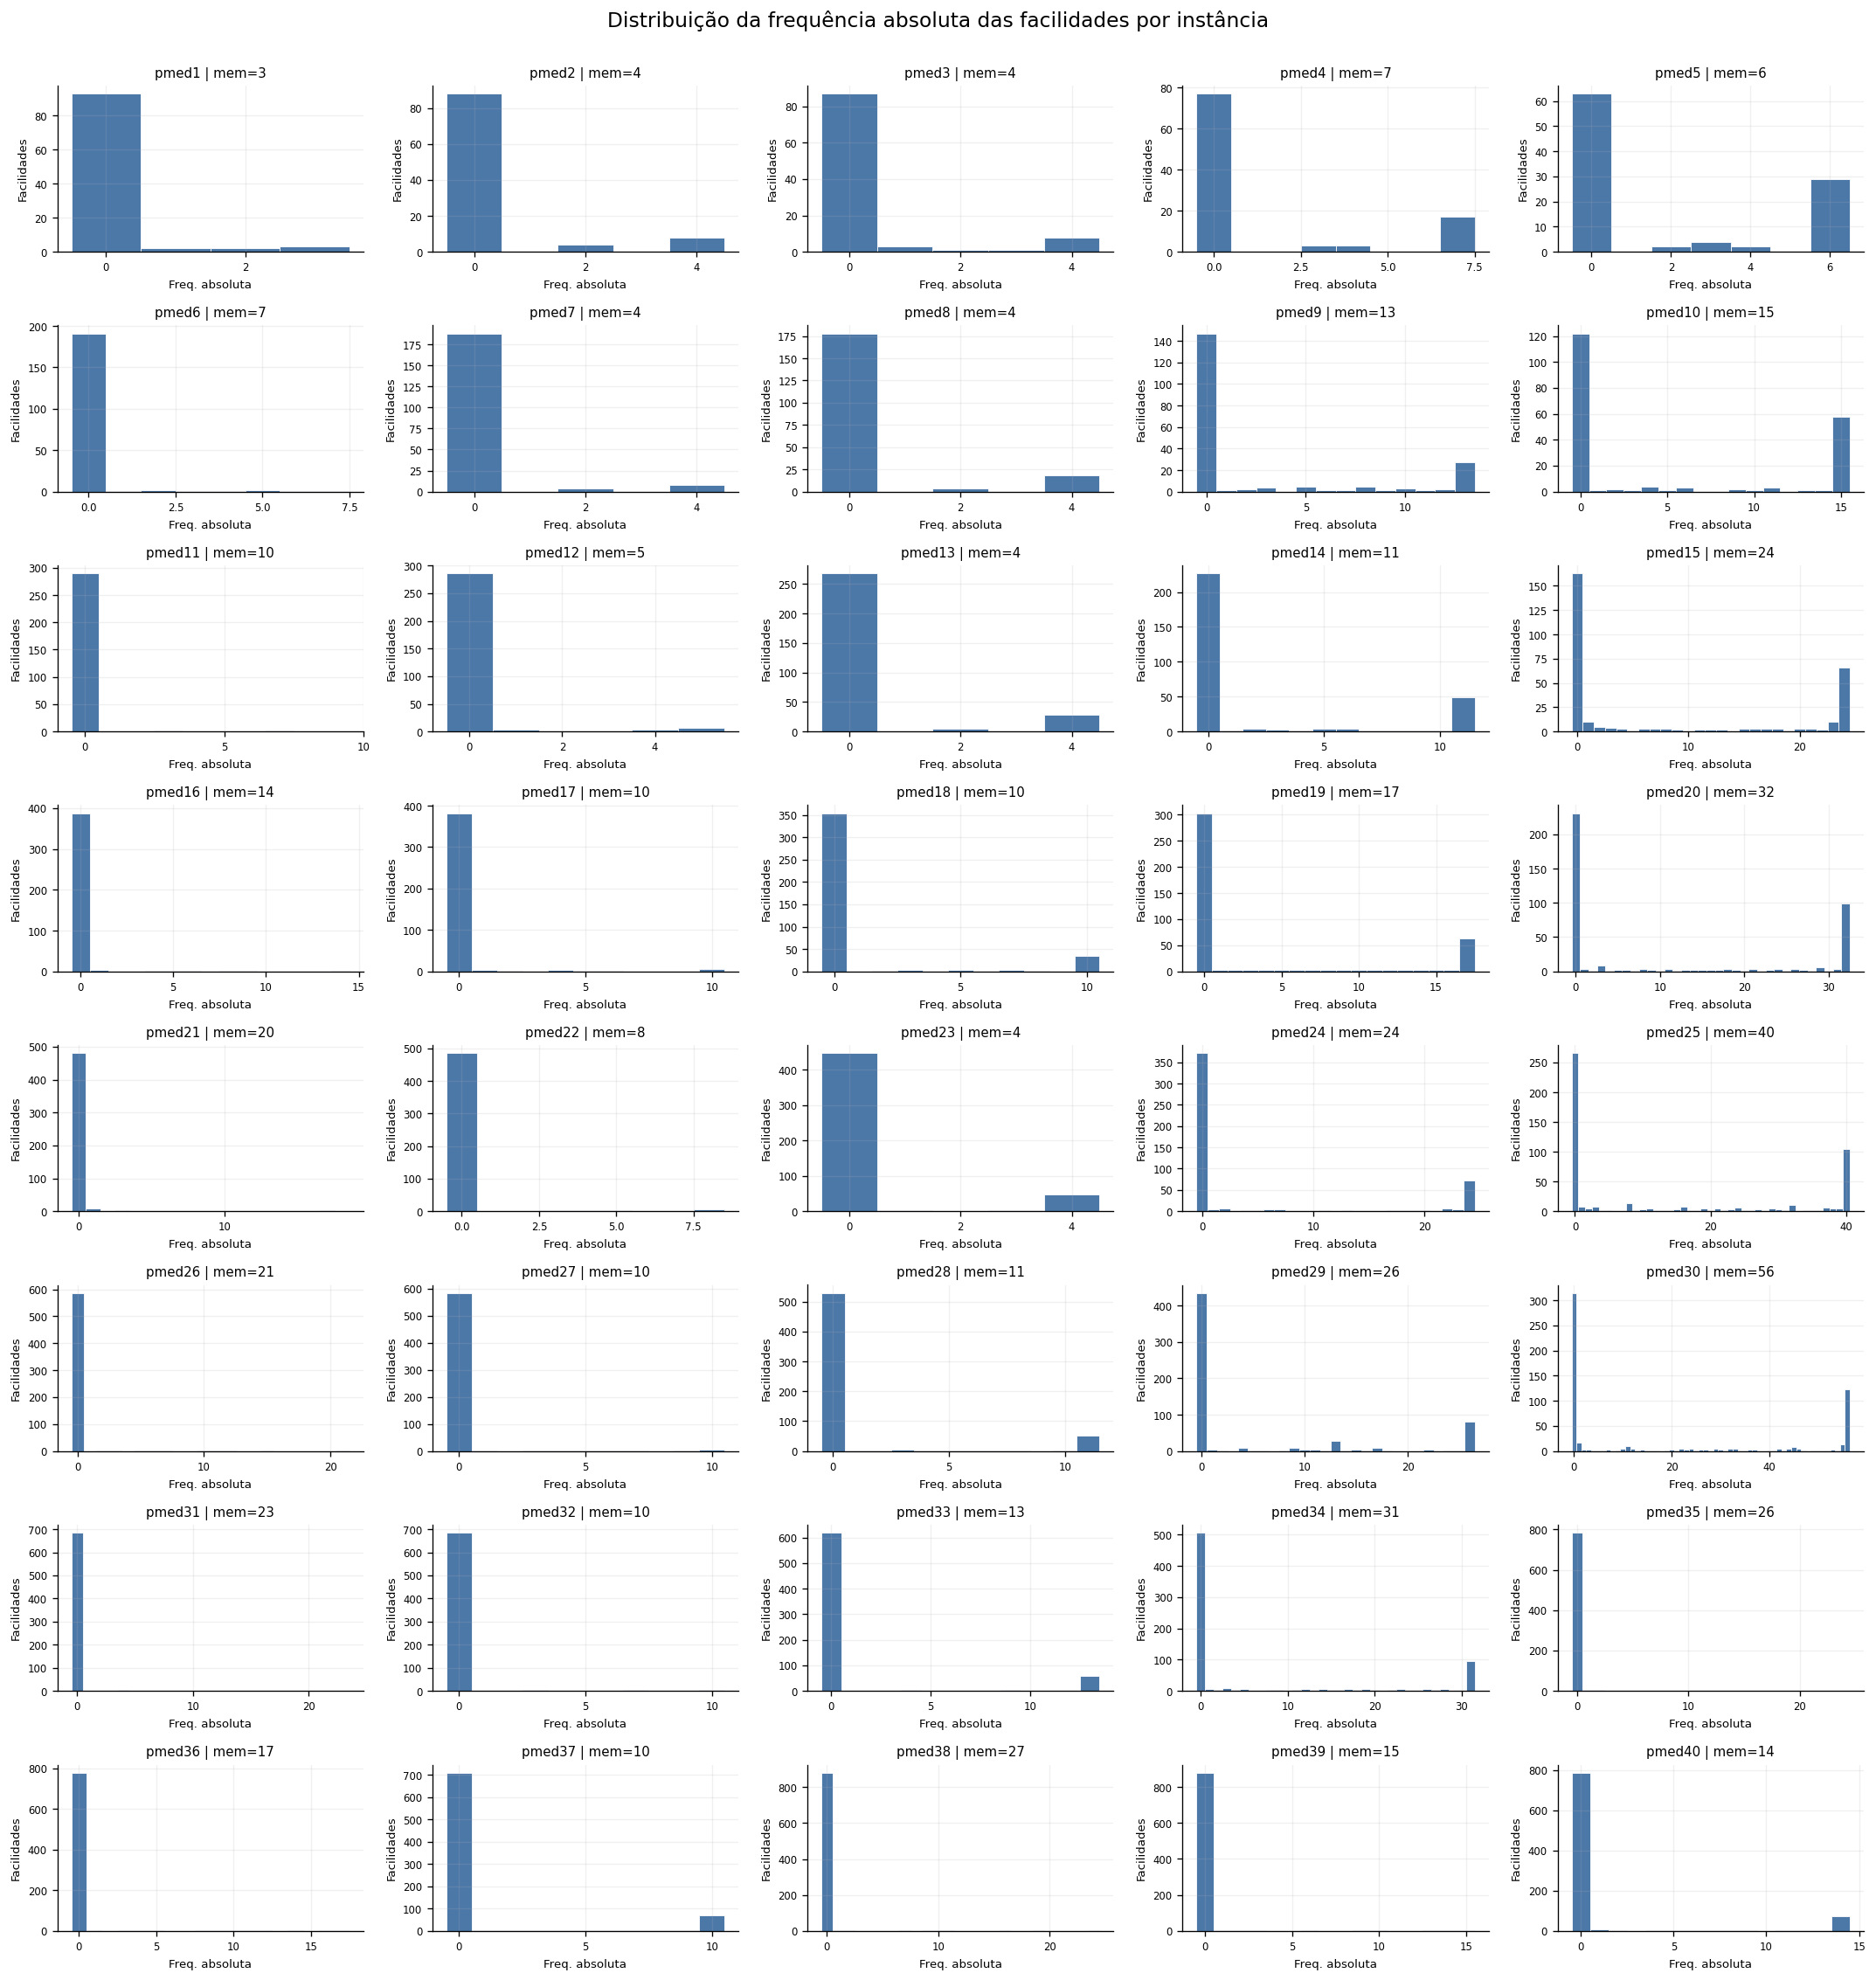

In [16]:
def plot_absolute_frequency_histograms(
    frequency_df   : pd.DataFrame,
    intersections  : pd.DataFrame,
    *,
    columns        : int = 5,
):
    plotted_instances = intersections.loc[
        intersections["status"] == "ok",
        [
            "instance"             ,
            "frequency_memory_size",
        ],
    ].reset_index(drop=True)

    if plotted_instances.empty:
        raise ValueError("No successful instance is available for plotting.")

    rows      = math.ceil   (len(plotted_instances) / columns)
    fig, axes = plt.subplots(
        rows   ,
        columns,
        figsize=(columns * 3.6, rows * 2.35),
        squeeze=False,
    )

    for ax in axes.ravel():
        ax.set_visible(False)

    for index, item in plotted_instances.iterrows():
        ax = axes[index // columns, index % columns]

        instance = item["instance"]
        subset   = frequency_df.loc[frequency_df["instance"] == instance]

        max_frequency = max(1, int(subset["absolute_frequency"].max()))
        bins          = np.arange(-0.5, max_frequency + 1.5, 1)

        ax.set_visible(True)
        ax.hist(
            subset["absolute_frequency"],
            bins     =bins       ,
            color    ="#4c78a8",
            edgecolor="white"    ,
            linewidth=0.5        ,
        )

        ax.set_title(
            f"{Path(instance).stem} | mem={int(item['frequency_memory_size'])}", fontsize=9
        )

        ax.set_xlabel    ("Freq. absoluta", fontsize=8)
        ax.set_ylabel    ("Facilidades"   , fontsize=8)
        ax.tick_params   (axis="both", labelsize=7)
        ax.locator_params(axis="x"   , nbins    =4)

    fig.suptitle(
        "Distribuição da frequência absoluta das facilidades por instância",
        fontsize=14   ,
        y       =1.002,
    )

    fig.tight_layout()

    return fig


absolute_frequency_fig = plot_absolute_frequency_histograms(
    facility_frequency_df, intersections_df
)

plt.show()

Global normalized frequency histogram:

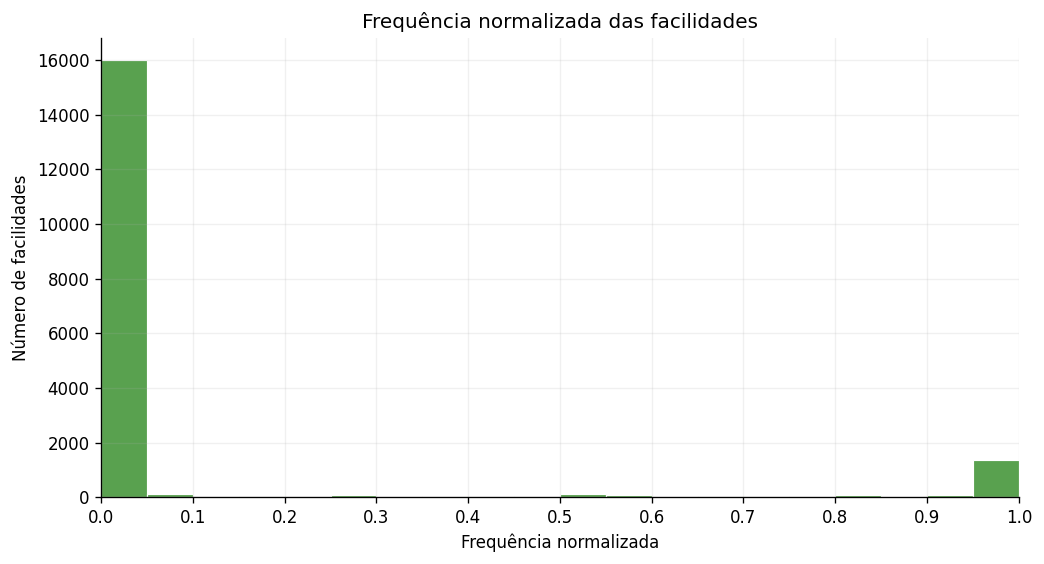

In [17]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))

bins = np.linspace(0.0, 1.0, 21)

ax.hist(
    facility_frequency_df["normalized_frequency"],
    bins     = bins       ,
    color    = "#59a14f",
    edgecolor= "white"    ,
    linewidth= 0.7        ,
)

ax.set_title ("Frequência normalizada das facilidades")
ax.set_xlabel("Frequência normalizada")
ax.set_ylabel("Número de facilidades" )

ax.set_xlim  (0.0, 1.0)
ax.set_xticks(np.linspace(0.0, 1.0, 11))

fig.tight_layout()

plt.show()

### SAVE RESULTS

In [18]:
if SAVE_RESULTS_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    intersections_df.to_csv(INTERSECTIONS_CSV, index=False)
    grouped_by_n_df .to_csv(GROUPED_BY_N_CSV , index=False)

    print(f"Intersections saved to : {INTERSECTIONS_CSV}")
    print(f"Grouped table saved to : { GROUPED_BY_N_CSV}")

if SAVE_FAILURES_CSV and not failure_df.empty:
    OUTPUT_DIR.mkdir (parents=True, exist_ok=True)

    failure_df.to_csv(FAILURES_CSV, index=False)

    print(f"Failures saved to : {FAILURES_CSV}")

Intersections saved to : /home/rei-luisinho/xopt/notebooks/experiments_sbpo/artifacts/structural_frequency_intersections.csv
Grouped table saved to : /home/rei-luisinho/xopt/notebooks/experiments_sbpo/artifacts/structural_frequency_grouped_by_n.csv
